<a href="https://colab.research.google.com/github/dbro-10/first_machine_learning_for_heart_disease/blob/main/final_heart_disease_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import os
import joblib

In [10]:
# Download dataset
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
print("Path to dataset files:", path)

# Find CSV
csv_path = None
for file in os.listdir(path):
    if file.endswith('.csv'):
        csv_path = os.path.join(path, file)
        print(f"Found CSV: {csv_path}")
        break

df = pd.read_csv(csv_path)
print(f"Loaded: {df.shape}")
df.head()

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data
Found CSV: /kaggle/input/heart-disease-data/heart_disease_uci.csv
Loaded: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Missing Values:
 id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol      

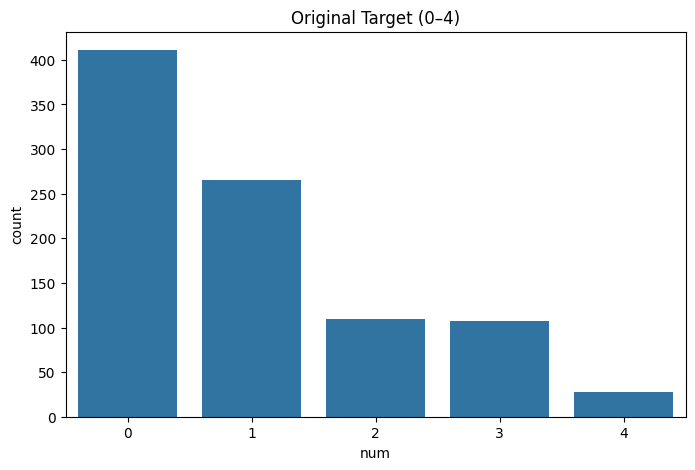

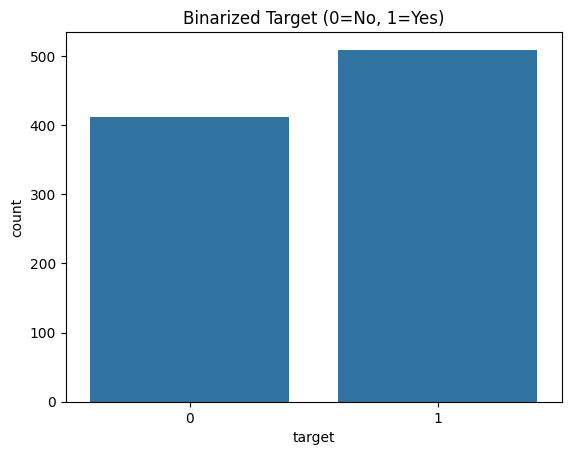

In [11]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

plt.figure(figsize=(8,5))
sns.countplot(x='num', data=df)
plt.title('Original Target (0–4)')
plt.show()

df['target'] = df['num'].apply(lambda x: 0 if x == 0 else 1)
sns.countplot(x='target', data=df)
plt.title('Binarized Target (0=No, 1=Yes)')
plt.show()

In [12]:
X = df.drop(['id', 'num', 'target'], axis=1)
y = df['target']

cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns

# Impute
X[cat_cols] = SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols])
X[num_cols] = SimpleImputer(strategy='mean').fit_transform(X[num_cols])

# Encode
for col in cat_cols:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Scale
X[num_cols] = StandardScaler().fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (736, 14), Test: (184, 14)


In [13]:
model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


Accuracy: 0.8424
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        82
           1       0.85      0.87      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



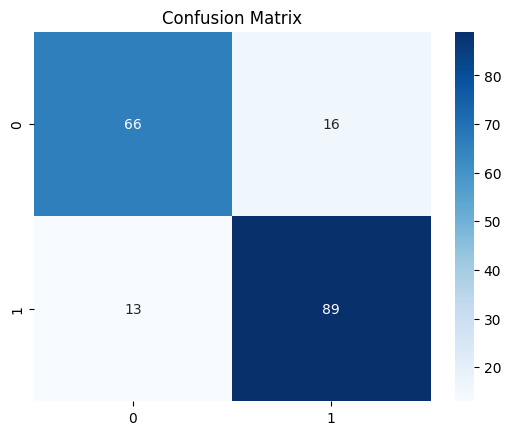

In [14]:
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

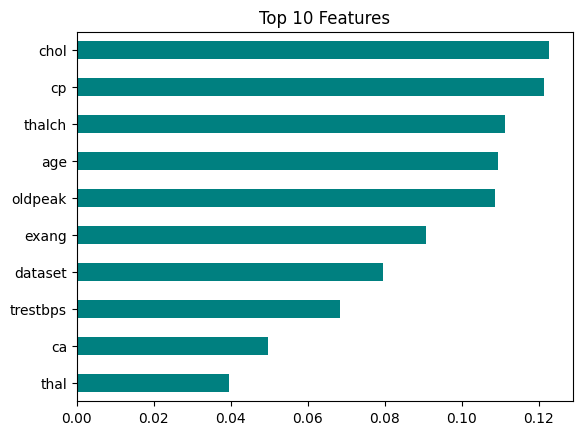

Model saved!


In [15]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Features')
plt.gca().invert_yaxis()
plt.show()

joblib.dump(model, 'heart_disease_model.pkl')
print("Model saved!")

In [16]:
# CELL 1: ROC-AUC Score
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
print(f"ROC-AUC Score: {auc:.4f}")

ROC-AUC Score: 0.9209


Type of shap_values: <class 'numpy.ndarray'>


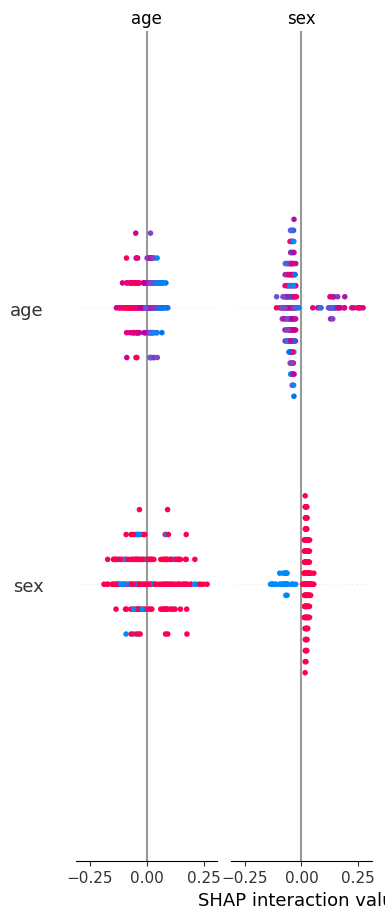

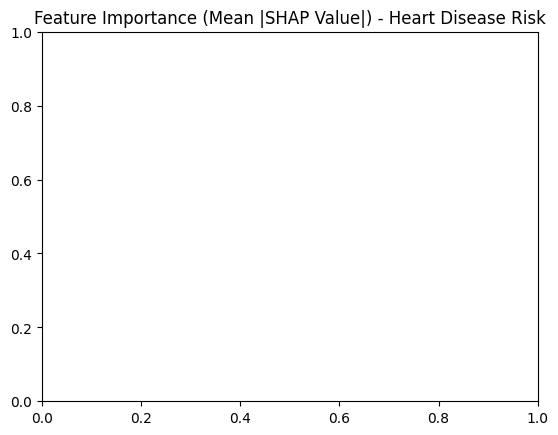

In [18]:
# CELL 2: SHAP Explainer (Bias Audit) - FIXED
import shap
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.TreeExplainer(model)

# Get SHAP values for POSITIVE class (target == 1)
# For binary classification, use index 1
shap_values = explainer.shap_values(X_test)

# Debug: Print type and shape
print(f"Type of shap_values: {type(shap_values)}")
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"SHAP values shape per class: {shap_values[0].shape}, {shap_values[1].shape}")

# Use only the positive class SHAP values (class 1)
shap_positive = shap_values[1] if isinstance(shap_values, list) else shap_values

# Plot summary (bar plot of mean absolute SHAP value per feature)
shap.summary_plot(shap_positive, X_test, plot_type="bar", max_display=10)
plt.title("Feature Importance (Mean |SHAP Value|) - Heart Disease Risk")
plt.show()